# Delhi Cars Selling Dataset For Cleaning

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
data=pd.read_csv('cars_delhiii.csv')

In [90]:
data.head(4)

,car_name,variant,transmission,km_driven,owner_type,fuel_type,registeration,price
0,2018 Tata NEXON,XM 1.2,Manual,"95,230 km",1st Owner,Petrol,UP-16,"₹6,50,000"
1,2017 Renault Kwid,1.0 RXT Opt,Manual,"72,956 km",2nd Owner,Petrol,HR-11,"₹3,19,000"
2,2017 HYUNDAI ELITE I20,ASTA 1.2 (O),Manual,"50,636 km",2nd Owner,Petrol,DL-7C,"₹5,87,000"
3,2019 Mahindra XUV 3OO,W8(O),Manual,"86,652 km",1st Owner,Diesel,DL-12,"₹8,22,000"


In [91]:
data.shape

(899, 8)

In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   car_name       899 non-null    object
 1   variant        899 non-null    object
 2   transmission   894 non-null    object
 3   km_driven      899 non-null    object
 4   owner_type     899 non-null    object
 5   fuel_type      899 non-null    object
 6   registeration  899 non-null    object
 7   price          899 non-null    object
dtypes: object(8)
memory usage: 56.3+ KB


In [93]:
data.isnull().sum()

car_name         0
variant          0
transmission     5
km_driven        0
owner_type       0
fuel_type        0
registeration    0
price            0
dtype: int64

In [94]:
data.dropna(inplace=True)

# Data cleaning for DA

# New Columns Based On One single column

In [95]:
data[['Year','Brand','Model']]=data['car_name'].str.split(" ",n=2,expand=True)

In [96]:
data.drop(columns=['car_name'],inplace=True)

# km_driven

In [97]:
data['km_driven']=data['km_driven'].str.replace(",","")

In [98]:
data['km_driven']=data['km_driven'].str.replace(" km","")

In [99]:
data['km_driven']=data['km_driven'].astype("int64")

In [100]:
data.head()

,variant,transmission,km_driven,owner_type,fuel_type,registeration,price,Year,Brand,Model
0,XM 1.2,Manual,95230,1st Owner,Petrol,UP-16,"₹6,50,000",2018,Tata,NEXON
1,1.0 RXT Opt,Manual,72956,2nd Owner,Petrol,HR-11,"₹3,19,000",2017,Renault,Kwid
2,ASTA 1.2 (O),Manual,50636,2nd Owner,Petrol,DL-7C,"₹5,87,000",2017,HYUNDAI,ELITE I20
3,W8(O),Manual,86652,1st Owner,Diesel,DL-12,"₹8,22,000",2019,Mahindra,XUV 3OO
4,1.5 SX (O) AT,Automatic,20235,1st Owner,Petrol,DL-9C,"₹16,74,000",2020,Hyundai,Creta


# Price

In [101]:
data['price']=data['price'].str.replace("₹","")

In [102]:
data['price']=data['price'].str.replace(",","")

# State_code

In [103]:
data['State_code']=data['registeration'].str.split("-").str[0]

In [104]:
data.drop(columns=['registeration'],inplace=True)

# Data Cleaning For ML

# Labelling

In [105]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [106]:
varient_en=LabelEncoder()
data['variant']=varient_en.fit_transform(data['variant'])

In [107]:
transmission_en=LabelEncoder()
data['transmission']=transmission_en.fit_transform(data['transmission'])

In [108]:
owner_type_en=LabelEncoder()
data['owner_type']=owner_type_en.fit_transform(data['owner_type'])

In [109]:
fuel_type_en=LabelEncoder()
data['fuel_type']=fuel_type_en.fit_transform(data['fuel_type'])

In [110]:
Brand_en=LabelEncoder()
data['Brand']=Brand_en.fit_transform(data['Brand'])

In [111]:
State_code_en=LabelEncoder()
data['State_code']=State_code_en.fit_transform(data['State_code'])

In [112]:
Model_en=LabelEncoder()
data['Model']=Model_en.fit_transform(data['Model'])

# Outliers Checking

In [116]:
data.head()

,variant,transmission,km_driven,owner_type,fuel_type,price,Year,Brand,Model,State_code
0,314,1,95230,0,2,650000,2018,22,70,2
1,6,1,72956,1,2,319000,2017,17,62,1
2,106,1,50636,1,2,587000,2017,5,33,0
3,310,1,86652,0,1,822000,2019,12,118,0
4,53,0,20235,0,2,1674000,2020,7,27,0


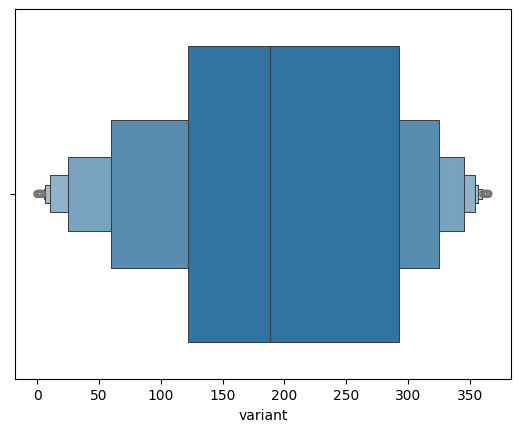

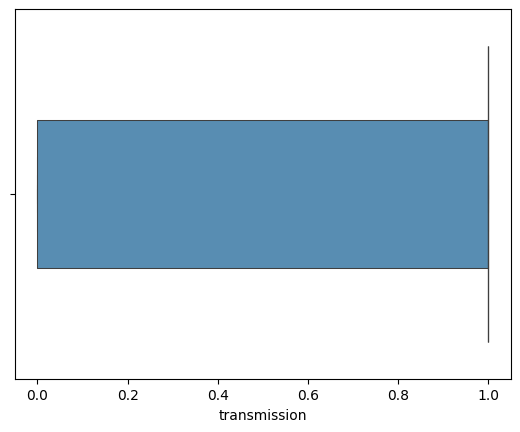

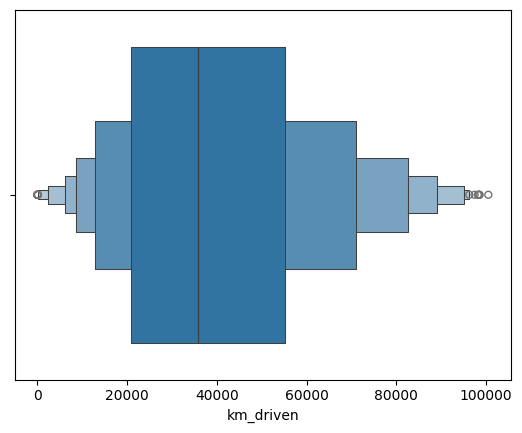

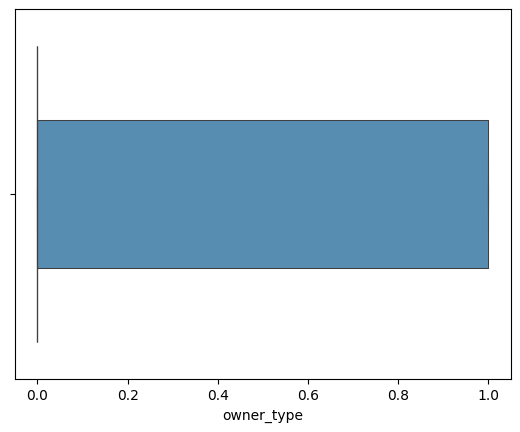

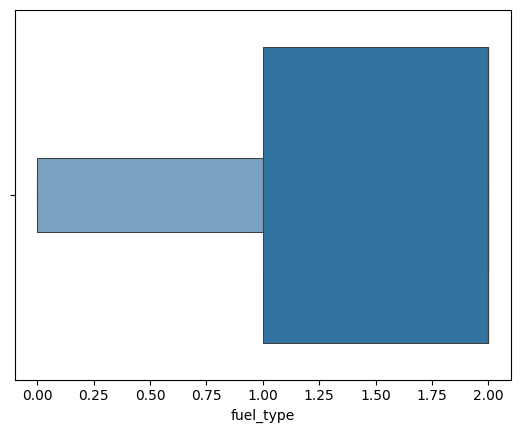

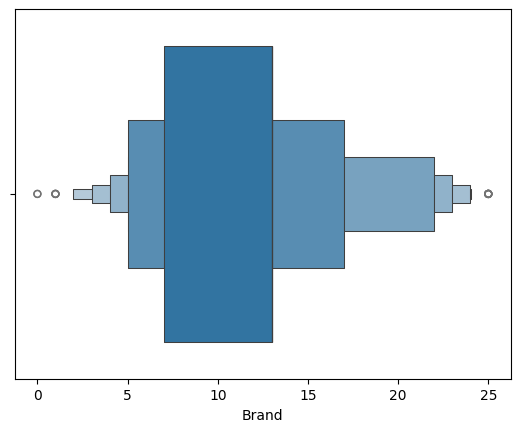

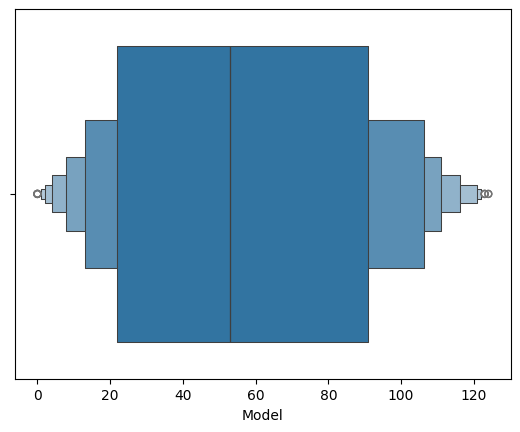

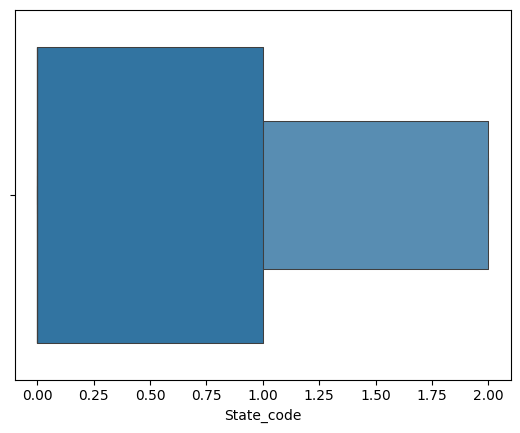

In [118]:
for i in data.select_dtypes(include="number").columns:
    sns.boxenplot(x=data[i],data=data)
    plt.show()

# Scalling

In [114]:
ss=StandardScaler()
new_data=pd.DataFrame(ss.fit_transform(data),columns=data.columns)


# Final Data For ML

In [115]:
new_data

,variant,transmission,km_driven,owner_type,fuel_type,price,Year,Brand,Model,State_code
0,1.152211,0.524710,2.349972,-0.425415,0.544390,-0.180846,-0.099916,2.056891,0.377039,1.904367
1,-1.850957,0.524710,1.409626,2.350648,0.544390,-1.203682,-0.504102,1.089884,0.159221,0.539087
2,-0.875902,0.524710,0.467337,2.350648,0.544390,-0.375525,-0.504102,-1.230933,-0.630368,-0.826193
3,1.113209,0.524710,1.987833,-0.425415,-0.948508,0.350658,0.304270,0.122877,1.683945,-0.826193
4,-1.392681,-1.905813,-0.816109,-0.425415,0.544390,2.983456,0.708456,-0.844130,-0.793731,-0.826193
...,...,...,...,...,...,...,...,...,...,...
889,0.235660,-1.905813,-1.566478,-0.425415,0.544390,0.869801,1.112641,1.089884,0.131994,1.904367
890,-0.183613,0.524710,-0.390770,-0.425415,-2.441405,-0.835956,1.112641,0.316278,-1.528866,0.539087
891,-0.154362,0.524710,-0.345302,2.350648,-2.441405,-0.437328,0.708456,0.316278,0.431493,0.539087
892,-0.446878,0.524710,-1.128516,-0.425415,0.544390,1.738130,0.708456,-0.457327,0.812674,0.539087
